In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from statsbombpy import sb

matches = sb.matches(competition_id=37, season_id=281)
arsenal_matches = matches[
    (matches['home_team'] == 'Arsenal WFC') | (matches['away_team'] == 'Arsenal WFC')
]
arsenal_matches[['match_id', 'home_team', 'away_team', 'home_score', 'away_score', 'match_date']]

/Users/himankarsharma/.pyenv/versions/football-intelligence/lib/python3.12/site-packages/statsbombpy/api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,match_id,home_team,away_team,home_score,away_score,match_date
17,3913185,Arsenal WFC,Brighton & Hove Albion WFC,5,0,2024-05-18
22,3913169,Arsenal WFC,Leicester City WFC,3,0,2024-04-21
30,3913160,Arsenal WFC,Bristol City WFC,5,0,2024-04-14
35,3913156,Aston Villa W,Arsenal WFC,1,3,2024-03-24
39,3913152,Chelsea FCW,Arsenal WFC,3,1,2024-03-15
40,3913130,West Ham United LFC,Arsenal WFC,2,1,2024-02-04
41,3913135,Arsenal WFC,Manchester United W,3,1,2024-02-17
44,3913125,Liverpool WFC,Arsenal WFC,0,2,2024-01-28
47,3913117,Arsenal WFC,Everton LFC,2,1,2024-01-20
49,3913113,Tottenham Hotspur Women,Arsenal WFC,1,0,2023-12-16


In [3]:
matches[matches['match_id'] == 3913083][['match_id', 'home_team', 'away_team', 'home_score', 'away_score', 'match_date', 'competition_stage']]

,match_id,home_team,away_team,home_score,away_score,match_date,competition_stage
125,3913083,Arsenal WFC,Manchester City WFC,2,1,2023-11-05,Regular Season


In [4]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "models").exists():
            return candidate
    return start


repo_root = find_repo_root(Path.cwd())
if (repo_root / "src").exists():
    sys.path.insert(0, str(repo_root))

DATA_DIR = repo_root / "data" / "processed"
MODEL_PATH = repo_root / "models" / "xg_model.pkl"


In [5]:
from src.ingestion.loader import load_events

df = load_events(3913083)
df.dtypes


/Users/himankarsharma/.pyenv/versions/football-intelligence/lib/python3.12/site-packages/statsbombpy/api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


event_id           str
event_index      int64
match_id         int64
minute           int64
second           int64
period           int64
team               str
player             str
recipient          str
event_type         str
x              float64
y              float64
end_x          float64
end_y          float64
outcome            str
possession       int64
raw             object
dtype: object

In [6]:
from src.analytics.passing import calculate_progressive_passes

result = calculate_progressive_passes(df)
result.head(10)

,event_id,event_index,match_id,minute,second,period,team,player,recipient,event_type,x,y,end_x,end_y,outcome,possession,raw,progression
7,02d03d00-eec3-4412-b4e0-523b79a3cc62,7,3913083,0,3,1,Manchester City WFC,Alanna Stephanie Kennedy,Khadija Monifa Shaw,Pass,41.0,46.0,89.2,25.8,Incomplete,2,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",45.311742
10,4e7b9979-e576-459b-8852-9a85429c1e33,14,3913083,0,17,1,Arsenal WFC,Katie McCabe,Alessia Russo,Pass,49.2,80.0,77.0,77.4,Incomplete,3,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",24.329019
11,f849554a-9eb4-4e13-97c3-204962bbde63,18,3913083,0,19,1,Manchester City WFC,Laia Aleixandri López,Khadija Monifa Shaw,Pass,43.1,3.3,74.2,0.1,Out,4,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",24.466078
12,7e6f63f3-bd17-48d4-93d0-1d743f8f2d36,20,3913083,0,34,1,Arsenal WFC,Katie McCabe,Alessia Russo,Pass,56.0,80.0,77.4,76.3,Incomplete,5,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",19.503554
19,0f399782-9959-4b04-8904-9063a274eab3,51,3913083,1,1,1,Manchester City WFC,Laia Aleixandri López,Lauren Hemp,Pass,9.2,2.9,41.9,9.9,NaN,6,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",33.146685
30,b2490dd5-d358-4a29-b962-37f5b2df05f7,93,3913083,1,32,1,Manchester City WFC,Chloe Kelly,Khadija Monifa Shaw,Pass,100.0,68.7,103.0,26.5,NaN,6,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",13.272987
31,124b7591-301d-419e-ab5e-df6a4ca63788,98,3913083,2,2,1,Arsenal WFC,Manuela Zinsberger,Caitlin Jade Foord,Pass,7.0,36.1,49.1,14.8,NaN,7,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",37.822015
44,ebd6b738-2aa4-4890-93d3-c86b25c15673,146,3913083,3,16,1,Arsenal WFC,Katie McCabe,Alessia Russo,Pass,62.6,68.8,77.8,60.0,Incomplete,8,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",17.520470
52,1c49b04d-6286-4ab8-b926-9af2f1ad9ab7,178,3913083,3,43,1,Manchester City WFC,Chloe Kelly,Khadija Monifa Shaw,Pass,77.4,60.5,102.9,53.8,NaN,9,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",25.302044
53,c3b4a830-875e-48bd-9106-5b5d4859cde6,186,3913083,3,49,1,Arsenal WFC,Katie McCabe,Alessia Russo,Pass,10.7,37.2,52.6,40.4,NaN,9,"{'50_50': nan, 'bad_behaviour_card': nan, 'bal...",41.934672


In [7]:
raw_df = sb.events(match_id=3913083)
raw_df[raw_df["type"] == "Carry"]

/Users/himankarsharma/.pyenv/versions/football-intelligence/lib/python3.12/site-packages/statsbombpy/api_client.py:23: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,...,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
1989,NaN,NaN,NaN,NaN,NaN,NaN,"[43.1, 3.3]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:18.667,Carry,NaN
1990,NaN,NaN,NaN,NaN,NaN,NaN,"[56.8, 2.7]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:37.768,Carry,True
1991,NaN,NaN,NaN,NaN,NaN,NaN,"[49.7, 3.3]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:39.816,Carry,NaN
1992,NaN,NaN,NaN,NaN,NaN,NaN,"[41.3, 12.8]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:42.258,Carry,True
1993,NaN,NaN,NaN,NaN,NaN,NaN,"[26.9, 26.5]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,00:00:44.642,Carry,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2747,NaN,NaN,NaN,NaN,NaN,NaN,"[116.9, 75.1]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Arsenal WFC,968,01:02:22.343,Carry,True
2748,NaN,NaN,NaN,NaN,NaN,NaN,"[6.9, 15.1]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,01:02:27.697,Carry,NaN
2749,NaN,NaN,NaN,NaN,NaN,NaN,"[27.1, 47.5]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,01:02:29.678,Carry,NaN
2750,NaN,NaN,NaN,NaN,NaN,NaN,"[40.5, 66.4]",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Manchester City WFC,746,01:02:45.302,Carry,NaN


findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.


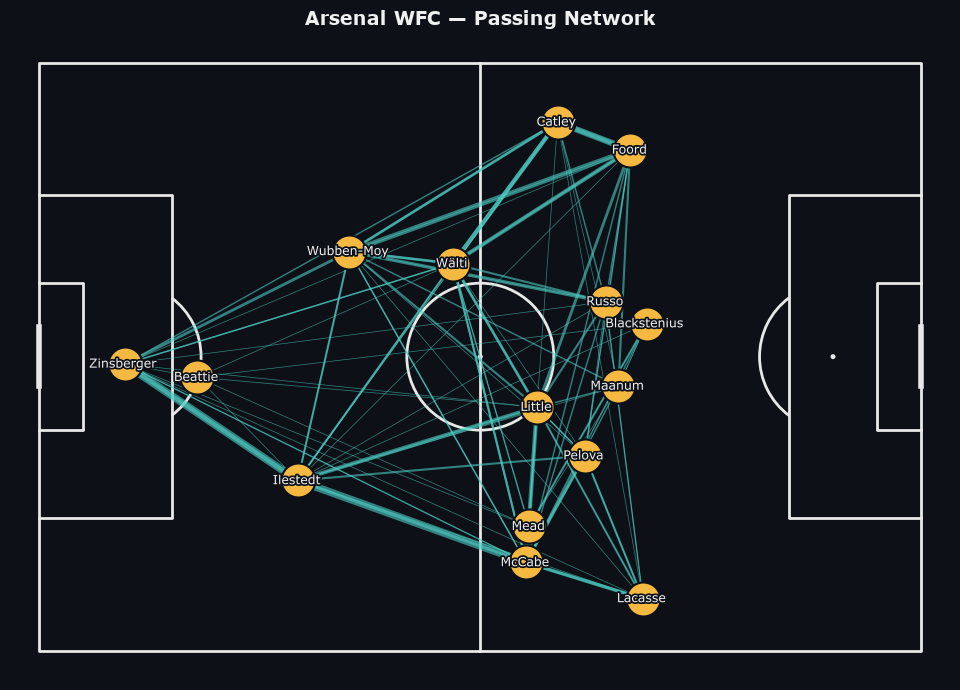

In [8]:
from src.ingestion.loader import load_events
from src.visualisation.pass_network import build_pass_network, plot_pass_network
import matplotlib.patheffects as pe

events = load_events(3913083)
nodes, edges = build_pass_network(events, team="Arsenal WFC")
fig = plot_pass_network(nodes, edges, title="Arsenal WFC — Passing Network")
fig.savefig("arsenal_pass_network.png")

In [9]:
from src.ingestion.loader import get_available_seasons

get_available_seasons(37)


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
25,37,281,England,FA Women's Super League,female,False,False,2023/2024,2026-04-11T13:05:10.794831,NaN,NaN,2026-04-11T13:05:10.794831
26,37,90,England,FA Women's Super League,female,False,False,2020/2021,2026-04-12T16:33:48.145602,2021-06-13T16:17:31.694,NaN,2026-04-12T16:33:48.145602
27,37,42,England,FA Women's Super League,female,False,False,2019/2020,2026-04-12T16:07:56.102610,2021-06-13T16:17:31.694,NaN,2026-04-12T16:07:56.102610
28,37,4,England,FA Women's Super League,female,False,False,2018/2019,2026-03-28T18:13:53.368475,2021-06-13T16:17:31.694,NaN,2026-03-28T18:13:53.368475


                  team  total_xg  actual_goals  shots
1  Manchester City WFC  1.507357             1     17
0          Arsenal WFC  0.540340             2      9


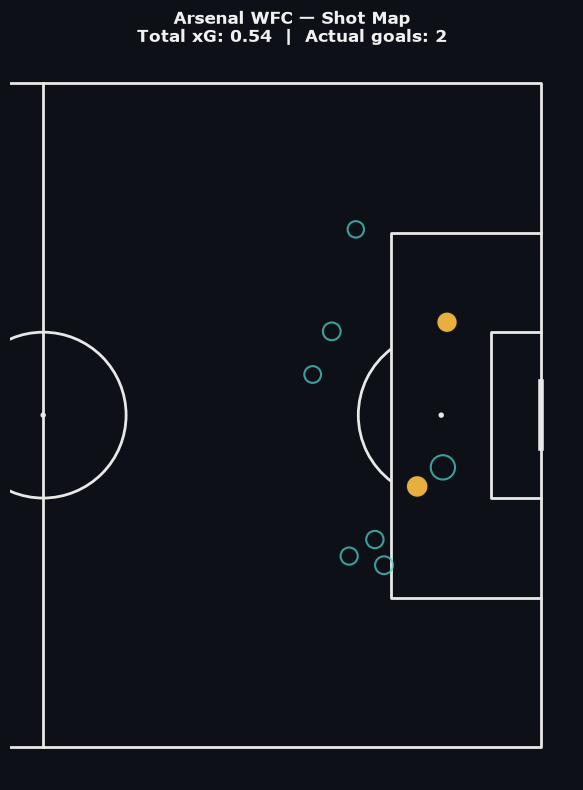

In [10]:
from src.ingestion.loader import load_events_cached
from src.visualisation.shot_map import build_shot_map_data, plot_shot_map, team_xg_summary
import pandas as pd

# Ensure this cell uses the same repo-root-based path resolution as the later cells
events = load_events_cached(3913083, cache_dir=str(DATA_DIR))

arsenal_shots = build_shot_map_data(events, team="Arsenal WFC")
fig = plot_shot_map(arsenal_shots, team="Arsenal WFC", title="Arsenal WFC — Shot Map")
fig.savefig("arsenal_shot_map.png")

city_shots = build_shot_map_data(events, team="Manchester City WFC")
all_shots = pd.concat([arsenal_shots, city_shots])
print(team_xg_summary(all_shots))


In [11]:
temp = build_shot_map_data(events, team="Arsenal WFC", model_path=str(MODEL_PATH))
temp.columns


Index(['event_id', 'match_id', 'minute', 'second', 'period', 'team', 'player',
       'recipient', 'event_type', 'x', 'y', 'end_x', 'end_y', 'outcome',
       'possession', 'raw', 'distance', 'angle', 'is_goal', 'shot_type',
       'is_penalty', 'is_free_kick', 'is_header', 'first_time',
       'under_pressure', 'technique', 'xg'],
      dtype='str')

In [12]:
from src.ingestion.loader import load_events_cached, get_all_match_ids
import pandas as pd
import joblib


COMPETITION_ID = 37
SEASON_IDS = [281, 90, 42, 4]

match_ids = get_all_match_ids(COMPETITION_ID, SEASON_IDS)

loaded_events = []
for i, match_id in enumerate(match_ids, start=1):
    try:
        loaded_events.append(load_events_cached(match_id, cache_dir=str(DATA_DIR)))
    except Exception as e:
        print(f"skip {match_id}: {e}")
    if i % 50 == 0:
        print(f"loaded {i}/{len(match_ids)}")

if loaded_events:
    all_events = pd.concat(loaded_events, ignore_index=True)
    print(f"Total events: {len(all_events)}")
else:
    raise RuntimeError("No events were loaded")

xg_model = joblib.load(MODEL_PATH)
events = all_events.iloc[:1].copy()
print(f"Loaded model from {MODEL_PATH}")


loaded 50/457
loaded 100/457
loaded 150/457
loaded 200/457
loaded 250/457
loaded 300/457
loaded 350/457
loaded 400/457
loaded 450/457
Total events: 1587305
Loaded model from /Users/himankarsharma/Documents/football-intelligence-copilot/models/xg_model.pkl


In [13]:
from src.analytics.xt_model import build_move_and_shot_data

data = build_move_and_shot_data(all_events, xg_model)


In [14]:
from src.analytics.xt_model import compute_xt_grid

xt_grid = compute_xt_grid(data, 500, 1e-5)


  iteration 10 — max change: 0.006250
  iteration 20 — max change: 0.003142
  iteration 30 — max change: 0.002657
  iteration 40 — max change: 0.002014
  iteration 50 — max change: 0.001338
  iteration 60 — max change: 0.000842
  iteration 70 — max change: 0.000517
  iteration 80 — max change: 0.000314
  iteration 90 — max change: 0.000190
  iteration 100 — max change: 0.000115
  iteration 110 — max change: 0.000069
  iteration 120 — max change: 0.000042
  iteration 130 — max change: 0.000025
  iteration 140 — max change: 0.000015
  iteration 149 — max change: 0.000010
Converged after 149 iterations (tolerance=1e-05).


In [15]:
all_actions = all_events[all_events["event_type"].isin(["Pass", "Carry", "Shot"])].dropna(subset=["x","y"]).copy()
is_shot = all_actions["event_type"] == "Shot"
is_completed_move = (~is_shot) & (all_actions["outcome"].isna())
actions = all_actions[is_shot | is_completed_move].copy()
kept_fraction = len(actions) / len(all_actions)
print(f"Kept {kept_fraction:.1%} of raw actions after filtering to shots+completed moves")


Kept 86.5% of raw actions after filtering to shots+completed moves


  iteration 10 — max change: 0.006250
  iteration 20 — max change: 0.003142
  iteration 30 — max change: 0.002657
  iteration 40 — max change: 0.002014
  iteration 50 — max change: 0.001338
  iteration 60 — max change: 0.000842
  iteration 70 — max change: 0.000517
  iteration 80 — max change: 0.000314
  iteration 90 — max change: 0.000190
  iteration 100 — max change: 0.000115
  iteration 110 — max change: 0.000069
  iteration 120 — max change: 0.000042
  iteration 130 — max change: 0.000025
  iteration 140 — max change: 0.000015
  iteration 149 — max change: 0.000010
Converged after 149 iterations (tolerance=1e-05).
  iteration 10 — max change: 0.000980
  iteration 20 — max change: 0.000167
  iteration 30 — max change: 0.000035
  iteration 38 — max change: 0.000009
Converged after 38 iterations (tolerance=1e-05).


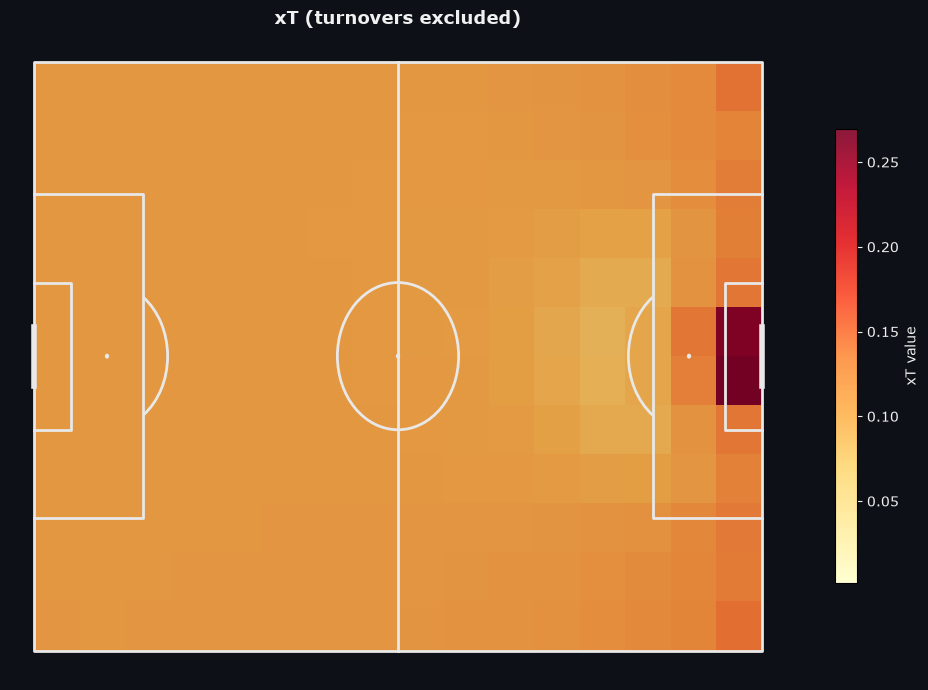

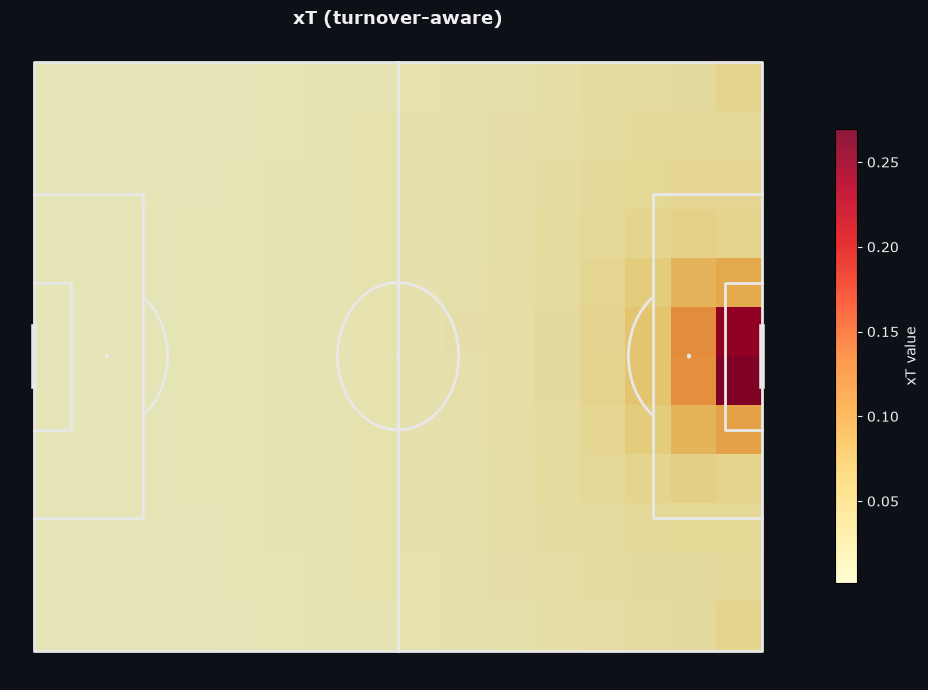

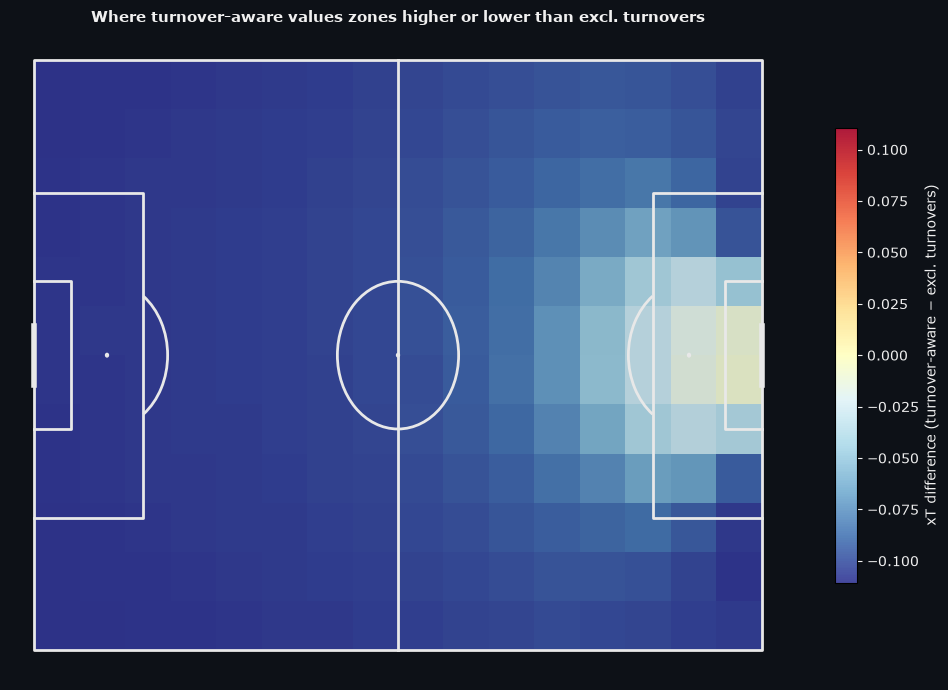

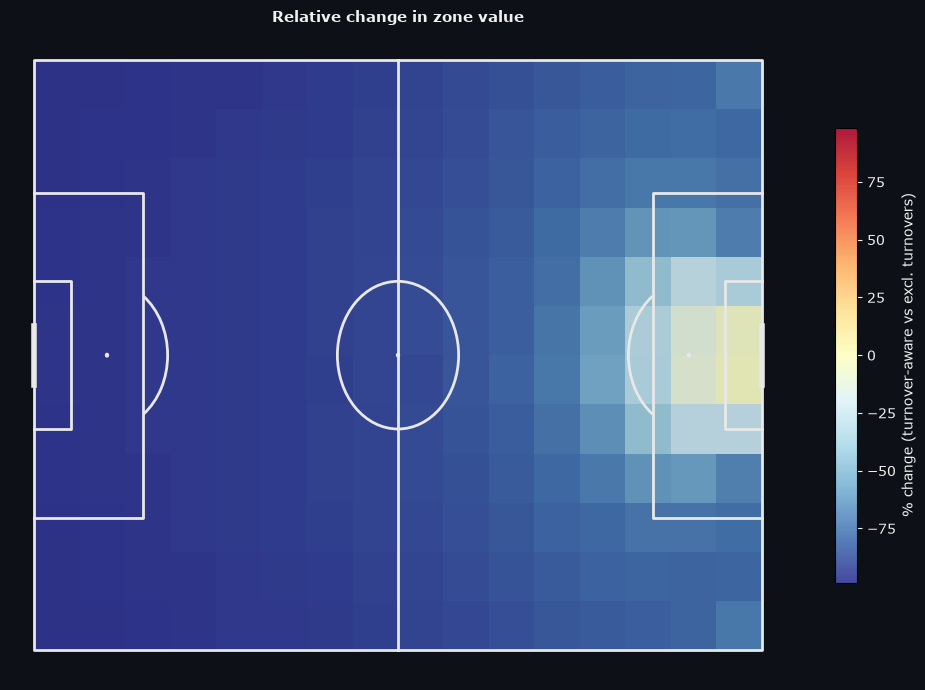

In [16]:
from src.analytics.xt_model import build_move_and_shot_data, compute_xt_grid
from src.visualisation.xt_heatmap import plot_xt_heatmap, plot_xt_diff, plot_xt_pct_change

data_no_turnover = build_move_and_shot_data(all_events, xg_model, include_turnovers=False)
xt_no_turnover = compute_xt_grid(data_no_turnover)

data_with_turnover = build_move_and_shot_data(all_events, xg_model, include_turnovers=True)
xt_with_turnover = compute_xt_grid(data_with_turnover)

shared_vmax = max(xt_no_turnover.max(), xt_with_turnover.max())
shared_vmin = min(xt_no_turnover.min(), xt_with_turnover.min())

fig1 = plot_xt_heatmap(xt_no_turnover, "xT (turnovers excluded)", vmin=shared_vmin, vmax=shared_vmax)
fig2 = plot_xt_heatmap(xt_with_turnover, "xT (turnover-aware)", vmin=shared_vmin, vmax=shared_vmax)
fig3 = plot_xt_diff(xt_no_turnover, xt_with_turnover, "excl. turnovers", "turnover-aware")
fig4 = plot_xt_pct_change(xt_no_turnover, xt_with_turnover, "excl. turnovers", "turnover-aware")

fig1.savefig("xt_no_turnover.png")
fig2.savefig("xt_with_turnover.png")
fig3.savefig("xt_diff.png")
fig4.savefig("xt_pct_change.png")

In [17]:
import numpy as np

# restrict to the attacking-third, central-channel region (roughly zone 14 + box-edge area)
# columns 9-13 (near box), rows 3-8 (central channels)
region_cols = range(9, 14)
region_rows = range(3, 9)

region_values = xt_no_turnover[np.ix_(region_cols, region_rows)]
min_local = np.unravel_index(np.argmin(region_values), region_values.shape)

actual_col = list(region_cols)[min_local[0]]
actual_row = list(region_rows)[min_local[1]]

print(f"Darkest cell in this region: (col={actual_col}, row={actual_row}), value={xt_no_turnover[actual_col, actual_row]:.4f}")

Darkest cell in this region: (col=12, row=5), value=0.0874


In [18]:
def inspect_zone(col, row, data):
    print(f"({col},{row}): "
          f"shot_prob={data['shot_prob'].get((col,row), 0):.4f}  "
          f"shot_value={data['shot_value'].get((col,row), 0):.4f}  "
          f"move_prob={data['move_prob'].get((col,row), 0):.4f}  "
          f"move_count={data['move_counts'].get((col,row), 0)}")

for dc in [-1, 0, 1]:
    for dr in [-1, 0, 1]:
        inspect_zone(actual_col + dc, actual_row + dr, data_no_turnover)

(11,4): shot_prob=0.0393  shot_value=0.0275  move_prob=0.9607  move_count=2346
(11,5): shot_prob=0.0631  shot_value=0.0261  move_prob=0.9369  move_count=2064
(11,6): shot_prob=0.0609  shot_value=0.0290  move_prob=0.9391  move_count=2266
(12,4): shot_prob=0.1339  shot_value=0.0463  move_prob=0.8661  move_count=2134
(12,5): shot_prob=0.1913  shot_value=0.0481  move_prob=0.8087  move_count=1492
(12,6): shot_prob=0.1987  shot_value=0.0489  move_prob=0.8013  move_count=1625
(13,4): shot_prob=0.2762  shot_value=0.0687  move_prob=0.7238  move_count=1271
(13,5): shot_prob=0.3610  shot_value=0.0864  move_prob=0.6390  move_count=1030
(13,6): shot_prob=0.3527  shot_value=0.0855  move_prob=0.6473  move_count=1105


In [19]:
for zone in [(11,4), (11,5), (11,6)]:
    dests = data_no_turnover["transition_counts"].loc[zone] if zone in data_no_turnover["transition_counts"].index.droplevel([2,3]).unique() else None
    print(zone, "-> top destinations:")
    print(data_no_turnover["transition_counts"].loc[zone].sort_values(ascending=False).head(5))
    print()

(11, 4) -> top destinations:
end_col  end_row
11       4          631
12       4          164
11       5          141
         3          119
10       4           95
dtype: int64

(11, 5) -> top destinations:
end_col  end_row
11       5          558
         6          162
         4          107
12       5           97
         4           94
dtype: int64

(11, 6) -> top destinations:
end_col  end_row
11       6          614
12       6          171
11       5          130
         7          126
12       7           96
dtype: int64



In [20]:
for zone in [(11,4), (11,5), (11,6)]:
    dests = data_no_turnover["transition_counts"].loc[zone]
    total = dests.sum()
    for (ec, er), count in dests.sort_values(ascending=False).head(5).items():
        print(f"{zone} -> ({ec},{er}): prob={count/total:.3f}, xT there={xt_no_turnover[ec,er]:.4f}")
    print()

(11, 4) -> (11,4): prob=0.269, xT there=0.1002
(11, 4) -> (12,4): prob=0.070, xT there=0.0931
(11, 4) -> (11,5): prob=0.060, xT there=0.0963
(11, 4) -> (11,3): prob=0.051, xT there=0.1055
(11, 4) -> (10,4): prob=0.040, xT there=0.1059

(11, 5) -> (11,5): prob=0.270, xT there=0.0963
(11, 5) -> (11,6): prob=0.078, xT there=0.0969
(11, 5) -> (11,4): prob=0.052, xT there=0.1002
(11, 5) -> (12,5): prob=0.047, xT there=0.0874
(11, 5) -> (12,4): prob=0.046, xT there=0.0931

(11, 6) -> (11,6): prob=0.271, xT there=0.0969
(11, 6) -> (12,6): prob=0.075, xT there=0.0884
(11, 6) -> (11,5): prob=0.057, xT there=0.0963
(11, 6) -> (11,7): prob=0.056, xT there=0.1023
(11, 6) -> (12,7): prob=0.042, xT there=0.0945



In [21]:
from src.analytics.xt_model import _zone_index

actions = all_events[all_events["event_type"].isin(["Pass", "Carry", "Shot"])].dropna(subset=["x", "y"]).copy()
actions["col"], actions["row"] = _zone_index(actions["x"].to_numpy(), actions["y"].to_numpy())

zone_actions = actions[(actions["col"] == 12) & (actions["row"].isin([4, 5, 6]))]
zone_actions["event_type"].value_counts()

event_type
Carry    3037
Pass     2971
Shot     1086
Name: count, dtype: int64

In [22]:
import numpy as np

zone_moves = zone_actions[zone_actions["event_type"].isin(["Pass", "Carry"])].dropna(subset=["end_x", "end_y"])
zone_moves["move_distance"] = np.sqrt(
    (zone_moves["end_x"] - zone_moves["x"])**2 + (zone_moves["end_y"] - zone_moves["y"])**2
)
zone_moves["move_distance"].describe()

count    6008.000000
mean        9.623577
std         8.509321
min         0.000000
25%         2.780288
50%         7.615773
75%        14.287232
max        59.481089
Name: move_distance, dtype: float64

In [23]:
sample_shot = all_events[all_events["event_type"] == "Shot"].iloc[0]["raw"]
[k for k in sample_shot.keys() if "shot" in k.lower() or "pressure" in k.lower() or "first_time" in k.lower()]

['goalkeeper_shot_saved_to_post',
 'pass_assisted_shot_id',
 'pass_shot_assist',
 'shot_aerial_won',
 'shot_body_part',
 'shot_end_location',
 'shot_first_time',
 'shot_freeze_frame',
 'shot_key_pass_id',
 'shot_one_on_one',
 'shot_open_goal',
 'shot_outcome',
 'shot_saved_to_post',
 'shot_statsbomb_xg',
 'shot_technique',
 'shot_type',
 'under_pressure']

In [24]:
sample_shots = all_events[all_events["event_type"] == "Shot"]["raw"]
print(sample_shots.apply(lambda r: r.get("shot_type")).value_counts())
print(sample_shots.apply(lambda r: r.get("shot_body_part")).value_counts())

raw
Open Play    11383
Free Kick      324
Penalty        105
Corner           4
Name: count, dtype: int64
raw
Right Foot    6714
Left Foot     3149
Head          1924
Other           29
Name: count, dtype: int64


In [25]:
from scripts.train_xg_model import build_shot_dataset, COMPETITION_ID, SEASON_IDS

all_shots = build_shot_dataset(COMPETITION_ID, SEASON_IDS)
for col in ["is_header", "is_free_kick", "under_pressure", "first_time"]:
    print(col, all_shots[col].value_counts().to_dict())

  processed 50/457
  processed 100/457
  processed 150/457
  processed 200/457
  processed 250/457
  processed 300/457
  processed 350/457
  processed 400/457
  processed 450/457
is_header {0: 9892, 1: 1924}
is_free_kick {0: 11492, 1: 324}
under_pressure {0: 9017, 1: 2799}
first_time {0: 8328, 1: 3488}


In [26]:
pd.crosstab(all_shots["is_free_kick"], all_shots["is_goal"])

is_goal,0,1
is_free_kick,,
0,10142,1350
1,296,28


In [27]:
import joblib
from pathlib import Path
print(Path.cwd())  # check your current working directory
XG_MODEL_PATH = Path("../models/xg_model.pkl")  # adjust path if your notebook's cwd differs, same as always
xg_model = joblib.load(XG_MODEL_PATH)

print(type(xg_model))  # should print <class 'dict'>, not <class 'sklearn.linear_model._logistic.LogisticRegression'>

/Users/himankarsharma/Documents/football-intelligence-copilot/notebooks
<class 'dict'>


In [28]:
from src.analytics.xt_model import build_move_and_shot_data
# compare shot_value zone-by-zone, old vs new, focusing on where the biggest shifts are
data = build_move_and_shot_data(all_events, xg_model)  # today's rebuilt xg_model
print(data["shot_value"].sort_values(ascending=False).head(10))
print(data["shot_value"].sort_values().head(10))

col  row
15   6      0.277231
     5      0.269315
14   6      0.147652
     5      0.144117
15   7      0.131151
     4      0.130455
14   4      0.108708
     7      0.106240
13   5      0.086435
     6      0.085481
Name: xg, dtype: float64
col  row
0    0      0.0
6    10     0.0
     9      0.0
     8      0.0
     7      0.0
     5      0.0
     4      0.0
     3      0.0
     2      0.0
     1      0.0
Name: xg, dtype: float64


In [29]:
# compare shot_value zone-by-zone, old vs new, focusing on where the biggest shifts are
data = build_move_and_shot_data(all_events, xg_model)  # today's rebuilt xg_model
print(data["shot_value"].sort_values(ascending=False).head(10))
print(data["shot_value"].sort_values().head(10))

col  row
15   6      0.277231
     5      0.269315
14   6      0.147652
     5      0.144117
15   7      0.131151
     4      0.130455
14   4      0.108708
     7      0.106240
13   5      0.086435
     6      0.085481
Name: xg, dtype: float64
col  row
0    0      0.0
6    10     0.0
     9      0.0
     8      0.0
     7      0.0
     5      0.0
     4      0.0
     3      0.0
     2      0.0
     1      0.0
Name: xg, dtype: float64


In [30]:
from src.analytics.xt_model import build_move_and_shot_data, compute_xt_grid

# Build both xT variants for comparison

data_no_turnover = build_move_and_shot_data(all_events, xg_model, include_turnovers=False)
xt_no_turnover = compute_xt_grid(data_no_turnover)

data_with_turnover = build_move_and_shot_data(all_events, xg_model, include_turnovers=True)
xt_with_turnover = compute_xt_grid(data_with_turnover)


  iteration 10 — max change: 0.006250
  iteration 20 — max change: 0.003142
  iteration 30 — max change: 0.002657
  iteration 40 — max change: 0.002014
  iteration 50 — max change: 0.001338
  iteration 60 — max change: 0.000842
  iteration 70 — max change: 0.000517
  iteration 80 — max change: 0.000314
  iteration 90 — max change: 0.000190
  iteration 100 — max change: 0.000115
  iteration 110 — max change: 0.000069
  iteration 120 — max change: 0.000042
  iteration 130 — max change: 0.000025
  iteration 140 — max change: 0.000015
  iteration 149 — max change: 0.000010
Converged after 149 iterations (tolerance=1e-05).
  iteration 10 — max change: 0.000980
  iteration 20 — max change: 0.000167
  iteration 30 — max change: 0.000035
  iteration 38 — max change: 0.000009
Converged after 38 iterations (tolerance=1e-05).


  iteration 10 — max change: 0.006250
  iteration 20 — max change: 0.003142
  iteration 30 — max change: 0.002657
  iteration 40 — max change: 0.002014
  iteration 50 — max change: 0.001338
  iteration 60 — max change: 0.000842
  iteration 70 — max change: 0.000517
  iteration 80 — max change: 0.000314
  iteration 90 — max change: 0.000190
  iteration 100 — max change: 0.000115
  iteration 110 — max change: 0.000069
  iteration 120 — max change: 0.000042
  iteration 130 — max change: 0.000025
  iteration 140 — max change: 0.000015
  iteration 149 — max change: 0.000010
Converged after 149 iterations (tolerance=1e-05).
  iteration 10 — max change: 0.000980
  iteration 20 — max change: 0.000167
  iteration 30 — max change: 0.000035
  iteration 38 — max change: 0.000009
Converged after 38 iterations (tolerance=1e-05).


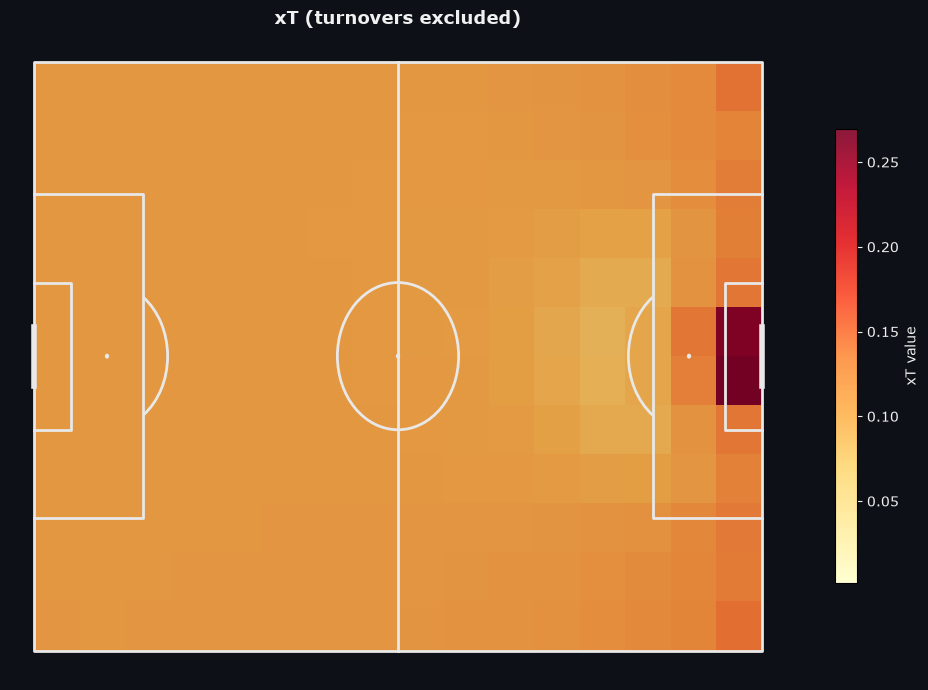

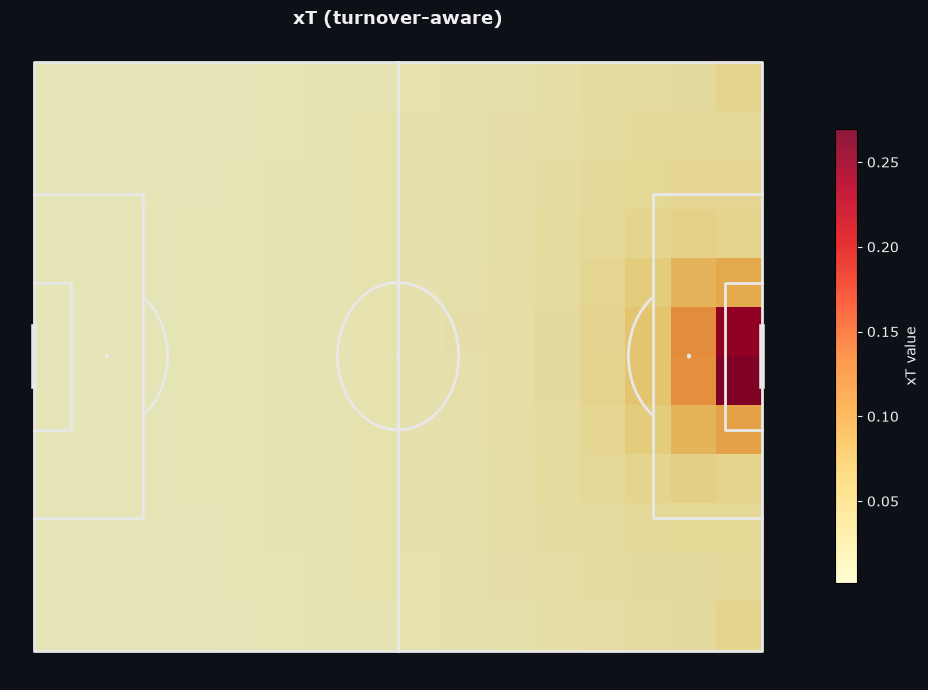

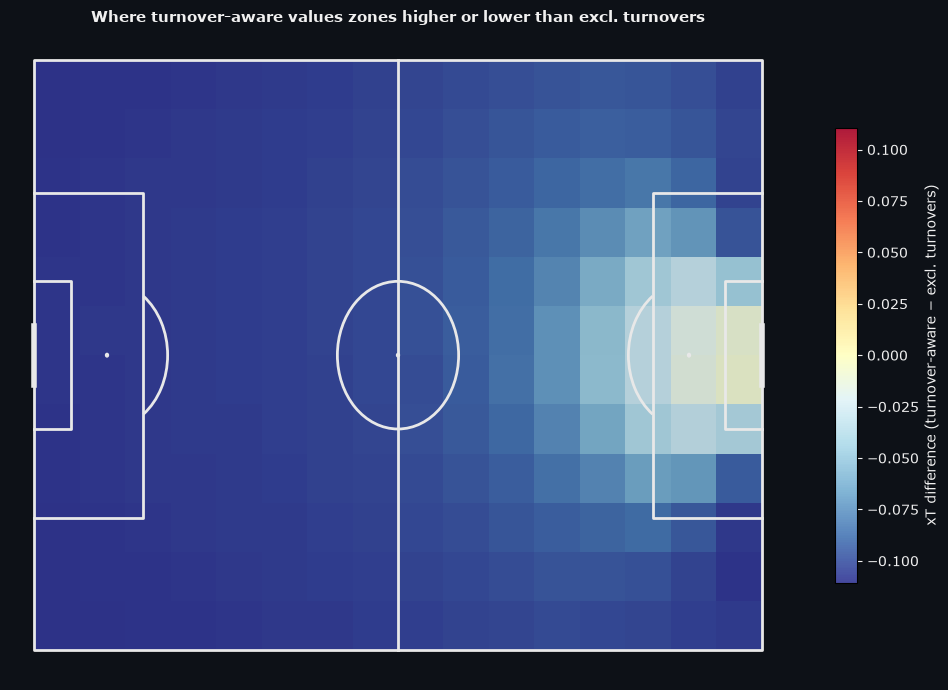

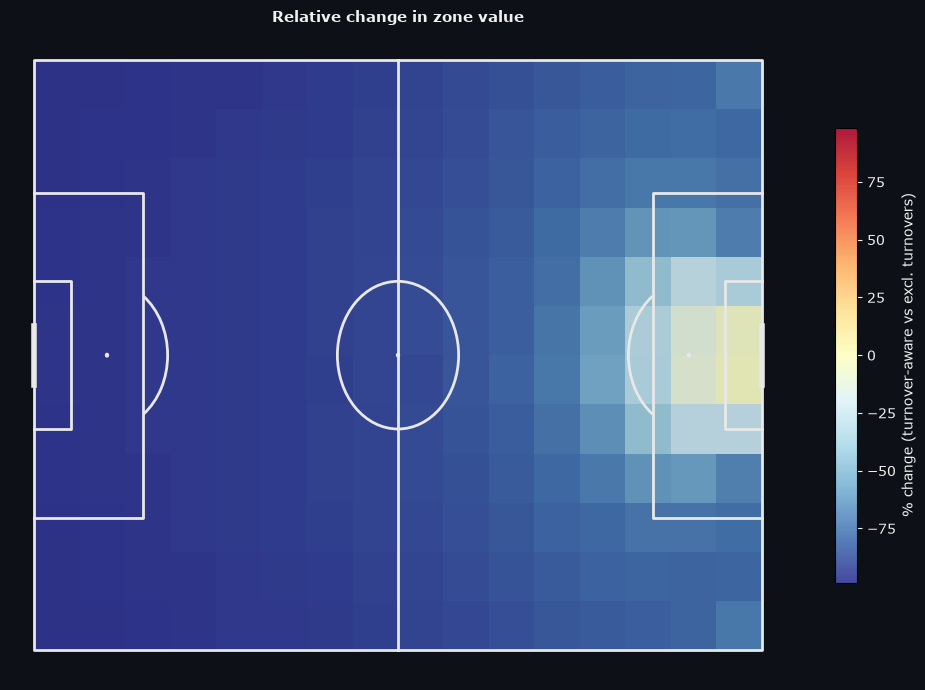

In [31]:
from src.analytics.xt_model import build_move_and_shot_data, compute_xt_grid
from src.visualisation.xt_heatmap import plot_xt_heatmap, plot_xt_diff, plot_xt_pct_change

# Rebuild the xT grids and save the plots

data_no_turnover = build_move_and_shot_data(all_events, xg_model, include_turnovers=False)
xt_no_turnover = compute_xt_grid(data_no_turnover)

data_with_turnover = build_move_and_shot_data(all_events, xg_model, include_turnovers=True)
xt_with_turnover = compute_xt_grid(data_with_turnover)

shared_vmax = max(xt_no_turnover.max(), xt_with_turnover.max())
shared_vmin = min(xt_no_turnover.min(), xt_with_turnover.min())

fig1 = plot_xt_heatmap(xt_no_turnover, "xT (turnovers excluded)", vmin=shared_vmin, vmax=shared_vmax)
fig2 = plot_xt_heatmap(xt_with_turnover, "xT (turnover-aware)", vmin=shared_vmin, vmax=shared_vmax)
fig3 = plot_xt_diff(xt_no_turnover, xt_with_turnover, "excl. turnovers", "turnover-aware")
fig4 = plot_xt_pct_change(xt_no_turnover, xt_with_turnover, "excl. turnovers", "turnover-aware")

fig1.savefig("xt_no_turnover.png")
fig2.savefig("xt_with_turnover.png")
fig3.savefig("xt_diff.png")
fig4.savefig("xt_pct_change.png")


In [32]:
from src.analytics.sequence_model import (
    tokenize_events, build_possession_sequences, build_transition_model,
    compute_action_surprise, compute_possession_perplexity, shuffled_baseline_sequences,
)
from sklearn.model_selection import train_test_split

# 1. tokenize, then split by MATCH (not possession) — same leakage discipline as xG/xT
tokenized = tokenize_events(all_events)
match_ids = tokenized["match_id"].unique()
train_ids, test_ids = train_test_split(match_ids, test_size=0.2, random_state=42)

train_sequences = build_possession_sequences(tokenized[tokenized["match_id"].isin(train_ids)])
test_sequences = build_possession_sequences(tokenized[tokenized["match_id"].isin(test_ids)])

# 2. fit on train only
model = build_transition_model(train_sequences, alpha=1.0)
print(f"Vocabulary size: {model['vocab_size']}")

# 3. MANDATORY sanity check before trusting anything — real sequences should
#    score lower average surprise than the same tokens shuffled within possession
real_surprise = compute_action_surprise(model, test_sequences)
shuffled_surprise = compute_action_surprise(model, shuffled_baseline_sequences(test_sequences))

print(f"Real avg surprise:     {real_surprise['surprise'].mean():.3f}")
print(f"Shuffled avg surprise: {shuffled_surprise['surprise'].mean():.3f}")

Vocabulary size: 280
Real avg surprise:     4.387
Shuffled avg surprise: 8.436


In [39]:
action_surprise = compute_action_surprise(model, test_sequences)

# tokenize_events already carries event_order — merge on the natural keys
# and keep the event locations needed for the later xT analysis.
tokenized_test = tokenized[tokenized["match_id"].isin(test_ids)].copy()
tokenized_test["position_in_possession"] = tokenized_test.groupby(["match_id", "possession"]).cumcount() + 1

merged = action_surprise.merge(
    tokenized_test[[
        "match_id",
        "possession",
        "position_in_possession",
        "player",
        "minute",
        "event_type",
        "x",
        "y",
        "end_x",
        "end_y",
    ]],
    on=["match_id", "possession", "position_in_possession"],
    how="left",
)

merged.sort_values("surprise", ascending=False).head(15)


,match_id,possession,position_in_possession,context_token,token,surprise,observed_count,context_total,player,minute,event_type,x,y,end_x,end_y
17401,19757,55,3,"(Pass, 4, 7)","(Carry, 0, 3)",12.792384,0,6814,Danique Kerkdijk,22,Pass,50.0,72.0,110.0,48.0
55687,2275094,218,4,"(Pass, 4, 7)","(Carry, 0, 3)",12.792384,0,6814,Hannah Hampton,96,Pass,58.6,77.7,117.8,49.5
23585,19772,105,6,"(Pass, 4, 7)","(Pass, 7, 1)",12.792384,0,6814,Josanne Potter,46,Pass,58.0,74.0,37.0,65.0
104126,3913073,80,11,"(Pass, 4, 7)","(Shot, 6, 2)",12.792384,0,6814,Noelle Maritz,46,Pass,56.0,76.2,46.7,62.0
20500,19770,127,1,"(Pass, 4, 7)","(Shot, 9, 5)",12.792384,0,6814,Gemma Bonner,57,Pass,57.0,80.0,114.0,59.0
119640,3913120,78,4,"(Pass, 4, 7)","(Pass, 0, 5)",12.792384,0,6814,Emma Wilhelmina Koivisto,50,Pass,55.7,77.3,10.0,51.0
128295,3913138,111,1,"(Pass, 0, 4)","(Dribble, 4, 0)",12.780540,0,6756,Khiara Keating,57,Pass,9.1,42.7,53.3,6.5
86148,3775623,94,1,"(Pass, 0, 4)","(Dribble, 2, 2)",12.780540,0,6756,Cecilie Fiskerstrand,35,Pass,6.0,44.0,28.5,38.9
11566,19740,31,1,"(Pass, 0, 4)","(Carry, 7, 7)",12.780540,0,6756,Rebecca Leigh Spencer,14,Pass,6.0,40.0,89.0,72.0
50210,2275074,133,3,"(Pass, 5, 7)","(Pass, 6, 3)",12.766322,0,6687,Hannah Jayne Blundell,61,Pass,70.2,76.2,83.2,58.4


In [38]:
sample_pass = all_events[all_events["event_type"] == "Pass"]["raw"].iloc[0]
[k for k in sample_pass.keys() if "type" in k.lower()]

['duel_type',
 'foul_committed_type',
 'goalkeeper_type',
 'pass_type',
 'shot_type',
 'type']

In [40]:
from src.analytics.xt_model import _zone_index

# Ensure the merged dataframe contains the location columns created above.
if "x" not in merged.columns or "y" not in merged.columns:
    raise KeyError("merged is missing x/y columns; run the preceding merge cell first.")

col_start, row_start = _zone_index(merged["x"].to_numpy(), merged["y"].to_numpy())
col_end, row_end = _zone_index(
    merged["end_x"].fillna(merged["x"]).to_numpy(),
    merged["end_y"].fillna(merged["y"]).to_numpy(),
)

merged["xt_start"] = xt_with_turnover[col_start, row_start]
merged["xt_end"] = xt_with_turnover[col_end, row_end]
merged["xt_delta"] = merged["xt_end"] - merged["xt_start"]

merged[["player", "minute", "event_type", "surprise", "xt_start", "xt_end", "xt_delta"]].head()


,player,minute,event_type,surprise,xt_start,xt_end,xt_delta
0,Lauren Hemp,0,Pass,3.661116,0.010616,0.007941,-0.002675
1,Georgia Stanway,0,Carry,1.107068,0.007941,0.007920,-0.000020
2,Georgia Stanway,0,Pass,7.231521,0.007920,0.005826,-0.002094
3,Stephanie Houghton,0,Carry,0.964791,0.005826,0.005826,0.000000
4,Stephanie Houghton,0,Pass,5.521422,0.005826,0.005011,-0.000815


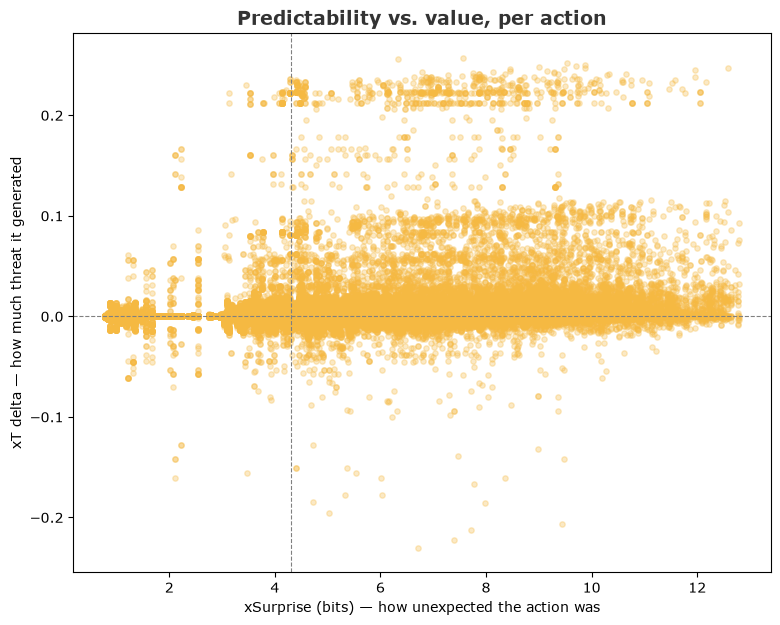

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(merged["surprise"], merged["xt_delta"], alpha=0.3, s=15, color="#f5b942")

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(merged["surprise"].median(), color="gray", linewidth=0.8, linestyle="--")

ax.set_xlabel("xSurprise (bits) — how unexpected the action was")
ax.set_ylabel("xT delta — how much threat it generated")
ax.set_title("Predictability vs. value, per action", color="#333", fontsize=14)

fig.savefig("xsurprise_vs_xt.png")

In [42]:
print(model["vocab_size"])

280


In [ ]:
# does high surprise correlate with anything real, or is it just noise?
print(merged[["surprise", "xt_delta"]].corr())

# the actual payoff: real names, real moments
merged.sort_values("surprise", ascending=False).head(10)[
    ["player", "minute", "event_type", "surprise", "xt_delta"]
]
merged[merged["xt_delta"] > merged["xt_delta"].quantile(0.95)].sort_values("surprise", ascending=False).head(10)[
    ["player", "minute", "event_type", "surprise", "xt_delta"]
]

          surprise  xt_delta
surprise  1.000000  0.197122
xt_delta  0.197122  1.000000


,player,minute,event_type,surprise,xt_delta
1586,Rebecca Leigh Spencer,1,Pass,12.126704,0.018742
11566,Rebecca Leigh Spencer,14,Pass,12.126704,0.015549
55542,Kenza Dali,80,Pass,12.123475,0.017738
40040,Angharad James,76,Pass,12.123475,0.089950
139322,Lisa Fjeldstad Naalsund,3,Pass,12.123475,0.055049
26085,Paige Williams,23,Pass,12.123475,0.017738
53018,Sophie Louise Ingle,17,Pass,12.123475,0.033181
18335,Sophie Harris,86,Pass,11.983706,0.019310
120863,Kirsty Smith,29,Pass,11.779309,0.107811
17756,Kirsty Barton,43,Pass,11.779309,0.107811


In [ ]:
import numpy as np
import pandas as pd

from src.analytics.sequence_model import token_probability


def compute_action_surprise_with_counts(model, sequences):
    rows = []
    for (match_id, possession), seq in sequences.items():
        for i in range(1, len(seq)):
            context, token = seq[i - 1], seq[i]
            c = model["counts"].get(context, {}).get(token, 0)
            p = token_probability(model, context, token)
            rows.append({
                "match_id": match_id,
                "possession": possession,
                "position_in_possession": i,
                "context_token": context,
                "token": token,
                "surprise": -np.log2(p) if p > 0 else np.inf,
                "observed_count": c,
            })
    return pd.DataFrame(rows)


action_surprise_v2 = compute_action_surprise_with_counts(model, test_sequences)

tokenized_test = tokenized[tokenized["match_id"].isin(test_ids)].copy()
tokenized_test["position_in_possession"] = tokenized_test.groupby(["match_id", "possession"]).cumcount() + 1

merged_v2 = action_surprise_v2.merge(
    tokenized_test[[
        "match_id",
        "possession",
        "position_in_possession",
        "player",
        "minute",
        "event_type",
        "x",
        "y",
        "end_x",
        "end_y",
    ]],
    on=["match_id", "possession", "position_in_possession"],
    how="left",
)

start_cols, start_rows = _zone_index(merged_v2["x"].to_numpy(), merged_v2["y"].to_numpy())
end_cols, end_rows = _zone_index(
    merged_v2["end_x"].fillna(merged_v2["x"]).to_numpy(),
    merged_v2["end_y"].fillna(merged_v2["y"]).to_numpy(),
)
merged_v2["xt_start"] = xt_with_turnover[start_cols, start_rows]
merged_v2["xt_end"] = xt_with_turnover[end_cols, end_rows]
merged_v2["xt_delta"] = merged_v2["xt_end"] - merged_v2["xt_start"]

# Keep only events that were actually observed in the training data,
# so the ranking highlights genuinely rare transitions rather than
# smoothing-floor cases that never appeared.
genuinely_rare = merged_v2[merged_v2["observed_count"] > 0].sort_values("surprise", ascending=False)
genuinely_rare.head(10)[["player", "minute", "event_type", "surprise", "observed_count", "xt_delta"]]


,player,minute,event_type,surprise,observed_count,xt_delta
8455,Megan Walsh,14,Pass,11.126704,1,0.011872
1526,Karen Bardsley,92,Pass,11.126704,1,0.009903
20433,Ellie Roebuck,50,Pass,11.126704,1,0.001081
89319,Hannah Hampton,55,Pass,11.126704,1,0.002733
32362,Megan Walsh,81,Pass,11.126704,1,0.001399
104741,Daphne van Domselaar,75,Pass,11.126704,1,0.001487
89499,Hannah Hampton,65,Pass,11.126704,1,0.002270
45563,Courtney Brosnan,64,Pass,11.126704,1,0.008471
73022,Alexandra MacIver,31,Pass,11.126704,1,-0.001236
132731,Alex Greenwood,24,Pass,11.126704,1,0.014455


In [ ]:
context_totals = pd.Series({ctx: model["context_totals"].get(ctx, 0) for ctx in merged_v2["context_token"].unique()})
merged_v2["context_total"] = merged_v2["context_token"].map(context_totals)

MIN_CONTEXT_VOLUME = 50  # only trust surprise estimates from reasonably well-observed starting zones

reliable_surprising = merged_v2[
    (merged_v2["observed_count"] > 0) & (merged_v2["context_total"] >= MIN_CONTEXT_VOLUME)
].sort_values("surprise", ascending=False)

reliable_surprising.head(10)[["player", "minute", "event_type", "surprise", "observed_count", "context_total", "xt_delta"]]

,player,minute,event_type,surprise,observed_count,context_total,xt_delta
132731,Alex Greenwood,24,Pass,11.126704,1,3816,0.014455
73022,Alexandra MacIver,31,Pass,11.126704,1,3816,-0.001236
32362,Megan Walsh,81,Pass,11.126704,1,3816,0.001399
75195,Mary Alexandra Earps,88,Pass,11.126704,1,3816,0.003869
8455,Megan Walsh,14,Pass,11.126704,1,3816,0.011872
89319,Hannah Hampton,55,Pass,11.126704,1,3816,0.002733
45563,Courtney Brosnan,64,Pass,11.126704,1,3816,0.008471
89499,Hannah Hampton,65,Pass,11.126704,1,3816,0.002270
1526,Karen Bardsley,92,Pass,11.126704,1,3816,0.009903
20433,Ellie Roebuck,50,Pass,11.126704,1,3816,0.001081


In [ ]:
from statsbombpy import sb

comps = sb.competitions()
comps[comps["competition_gender"] == "female"][
    ["competition_id", "competition_name", "season_id", "season_name"]
].sort_values(["competition_name", "season_name"])

,competition_id,competition_name,season_id,season_name
28,37,FA Women's Super League,4,2018/2019
27,37,FA Women's Super League,42,2019/2020
26,37,FA Women's Super League,90,2020/2021
25,37,FA Women's Super League,281,2023/2024
38,135,Frauen Bundesliga,281,2023/2024
58,182,Liga F,281,2023/2024
67,49,NWSL,3,2018
66,49,NWSL,107,2023
72,131,Serie A Women,281,2023/2024
77,53,UEFA Women's Euro,106,2022


In [45]:
from src.ingestion.loader import get_all_match_ids, load_events_cached
import pandas as pd

CLUB_COMPETITIONS = [
    (37, [4, 42, 90, 281]),   # FA WSL
    (135, [281]),              # Frauen Bundesliga
    (182, [281]),               # Liga F
    (49, [3, 107]),             # NWSL
    (131, [281]),                # Serie A Women
]

def load_multi_competition_events(competition_season_pairs):
    all_match_ids = []
    for competition_id, season_ids in competition_season_pairs:
        all_match_ids.extend(get_all_match_ids(competition_id, season_ids))
    print(f"Total matches: {len(all_match_ids)}")

    all_events = []
    for i, match_id in enumerate(all_match_ids, start=1):
        try:
            all_events.append(load_events_cached(match_id))
        except Exception as e:
            print(f"  [skip] {match_id}: {e}")
        if i % 100 == 0:
            print(f"  loaded {i}/{len(all_match_ids)}")
    return pd.concat(all_events, ignore_index=True), all_match_ids

club_events, club_match_ids = load_multi_competition_events(CLUB_COMPETITIONS)

from sklearn.model_selection import train_test_split
from src.analytics.sequence_model import (
    tokenize_events, build_possession_sequences, build_transition_model,
    compute_action_surprise, shuffled_baseline_sequences,
)

def run_experiment(events_df, n_cols, n_rows, label):
    tokenized = tokenize_events(events_df, n_cols=n_cols, n_rows=n_rows)
    match_ids = tokenized["match_id"].unique()
    train_ids, test_ids = train_test_split(match_ids, test_size=0.2, random_state=42)

    train_seqs = build_possession_sequences(tokenized[tokenized["match_id"].isin(train_ids)])
    test_seqs = build_possession_sequences(tokenized[tokenized["match_id"].isin(test_ids)])

    model = build_transition_model(train_seqs, alpha=1.0)

    real = compute_action_surprise(model, test_seqs)
    shuffled = compute_action_surprise(model, shuffled_baseline_sequences(test_seqs))

    print(f"--- {label} ---")
    print(f"Matches: {len(match_ids)}  Vocab size: {model['vocab_size']}")
    print(f"Real avg surprise: {real['surprise'].mean():.3f}  Shuffled: {shuffled['surprise'].mean():.3f}")

    reliable = real[(real["observed_count"] > 0) & (real["context_total"] >= 50)]
    print(f"Reliable high-surprise actions available: {len(reliable)}\n")

    return {"model": model, "real_surprise": real, "test_sequences": test_seqs, "tokenized": tokenized}


# Run A: grid only — same WSL data, coarser resolution
result_a = run_experiment(all_events, n_cols=10, n_rows=8, label="A: WSL + coarse grid")

# Run B: leagues only — more data, original finer resolution (isolates the data-volume effect)
result_b = run_experiment(club_events, n_cols=16, n_rows=12, label="B: 5 leagues + fine grid")

# Run C: combined
result_c = run_experiment(club_events, n_cols=10, n_rows=8, label="C: 5 leagues + coarse grid")

Total matches: 1132
  loaded 100/1132
  loaded 200/1132
  loaded 300/1132
  loaded 400/1132
  loaded 500/1132
  loaded 600/1132
  loaded 700/1132
  loaded 800/1132
  loaded 900/1132
  loaded 1000/1132
  loaded 1100/1132
--- A: WSL + coarse grid ---
Matches: 457  Vocab size: 280
Real avg surprise: 4.387  Shuffled: 8.436
Reliable high-surprise actions available: 144684

--- B: 5 leagues + fine grid ---
Matches: 1132  Vocab size: 675
Real avg surprise: 5.518  Shuffled: 9.472
Reliable high-surprise actions available: 338788

--- C: 5 leagues + coarse grid ---
Matches: 1132  Vocab size: 288
Real avg surprise: 4.379  Shuffled: 8.676
Reliable high-surprise actions available: 344041



In [46]:
merged_c = result_c["real_surprise"].merge(
    result_c["tokenized"].assign(position_in_possession=lambda df: df.groupby(["match_id","possession"]).cumcount()+1)
        [["match_id","possession","position_in_possession","player","minute","event_type"]],
    on=["match_id","possession","position_in_possession"], how="left"
)

reliable_c = merged_c[(merged_c["observed_count"] > 0) & (merged_c["context_total"] >= 50)]
reliable_c.sort_values("surprise", ascending=False).head(10)[
    ["player","minute","event_type","surprise","observed_count","context_total"]
]

,player,minute,event_type,surprise,observed_count,context_total
230352,María Miralles Gascón,59,Pass,13.028942,1,16428
331534,Amy Turner,88,Pass,13.028942,1,16428
323578,Shae Yanez,26,Pass,13.028942,1,16428
86144,Karima Benameur,21,Pass,13.028942,1,16428
176865,Leicy Maria Santos Herrera,95,Pass,12.966956,1,15725
303278,Julie Piga,81,Pass,12.963167,1,15683
154092,Shae Holmes,92,Pass,12.963167,1,15683
27958,Abigail Harrison,57,Pass,12.963167,1,15683
187970,Vilde Bøe Risa,79,Pass,12.932861,1,15351
139463,Samantha Hiatt,87,Pass,12.932861,1,15351


In [ ]:
print(len(club_match_ids), len(set(club_match_ids)))  # should be equal

1132 1132


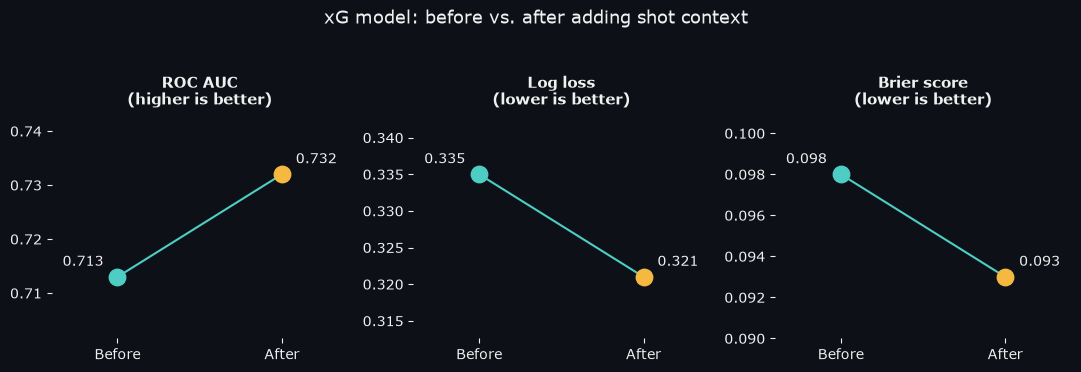

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

metrics = [
    ("ROC AUC", 0.713, 0.732, "higher is better"),
    ("Log loss", 0.335, 0.321, "lower is better"),
    ("Brier score", 0.098, 0.093, "lower is better"),
]

for ax, (name, before, after, direction) in zip(axes, metrics):
    ax.plot([0, 1], [before, after], color=ACCENT_TEAL, linewidth=1.5, zorder=1)
    ax.scatter([0], [before], color=ACCENT_TEAL, s=140, zorder=2)
    ax.scatter([1], [after], color=ACCENT_GOLD, s=140, zorder=2)

    pad = max(abs(after - before) * 0.6, 0.002)
    ax.set_ylim(min(before, after) - pad, max(before, after) + pad)
    ax.set_xlim(-0.4, 1.4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Before", "After"], color=TEXT_COLOR)

    ax.annotate(f"{before:.3f}", (0, before), textcoords="offset points", xytext=(-10, 8), ha="right", color=TEXT_COLOR, fontsize=10)
    ax.annotate(f"{after:.3f}", (1, after), textcoords="offset points", xytext=(10, 8), ha="left", color=TEXT_COLOR, fontsize=10)

    ax.set_title(f"{name}\n({direction})", color=TEXT_COLOR, fontsize=11)
    ax.tick_params(colors=TEXT_COLOR)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor(BG_COLOR)

fig.suptitle("xG model: before vs. after adding shot context", color=TEXT_COLOR, fontsize=13, y=1.05)
fig.patch.set_facecolor(BG_COLOR)
fig.tight_layout()
fig.savefig("xg_before_after.png", dpi=150, bbox_inches="tight")

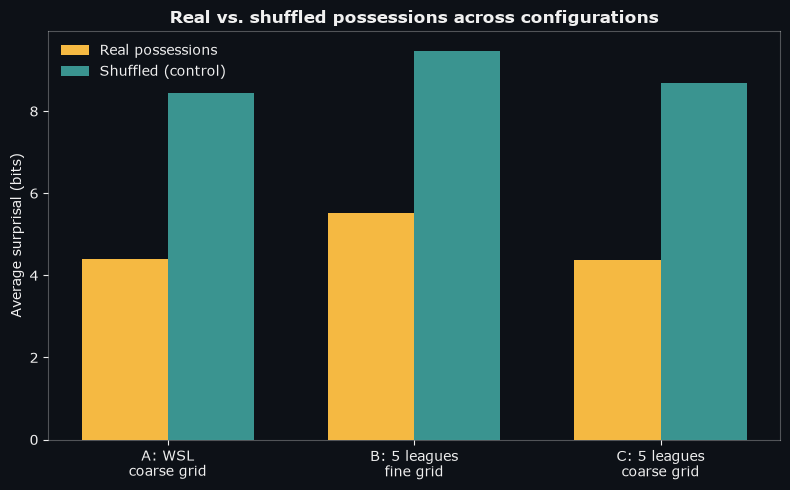

In [ ]:
import numpy as np

configs = ["A: WSL\ncoarse grid", "B: 5 leagues\nfine grid", "C: 5 leagues\ncoarse grid"]
real = [4.39, 5.52, 4.38]
shuffled = [8.44, 9.47, 8.68]

x = np.arange(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, real, width, label="Real possessions", color=ACCENT_GOLD)
ax.bar(x + width/2, shuffled, width, label="Shuffled (control)", color=ACCENT_TEAL, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(configs, color=TEXT_COLOR)
ax.set_ylabel("Average surprisal (bits)", color=TEXT_COLOR)
ax.set_title("Real vs. shuffled possessions across configurations", color=TEXT_COLOR)
ax.legend(facecolor=BG_COLOR, edgecolor="none", labelcolor=TEXT_COLOR)
ax.tick_params(colors=TEXT_COLOR)
for spine in ax.spines.values():
    spine.set_color(TEXT_COLOR)
    spine.set_alpha(0.3)

fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)
fig.tight_layout()
fig.savefig("perplexity_validation.png", dpi=150, bbox_inches="tight")

vocab_size: 288
merged rows: 345495


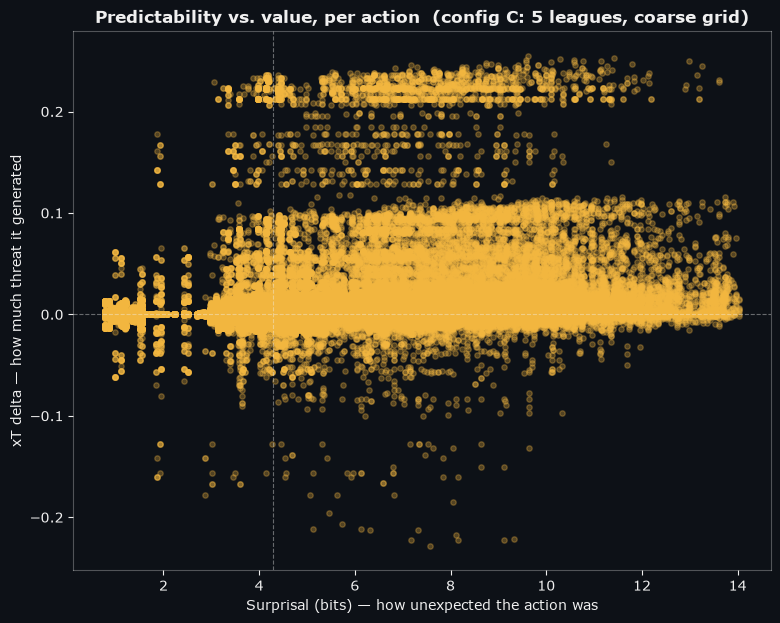

In [48]:
import matplotlib.pyplot as plt
from src.analytics.xt_model import _zone_index

# --- explicitly pull from result_c (5 leagues, coarse grid — the final configuration) ---
model = result_c["model"]
test_sequences = result_c["test_sequences"]
tokenized = result_c["tokenized"]

print(f"vocab_size: {model['vocab_size']}")  # sanity check — should be ~280-288 for the coarse grid

# --- recompute action_surprise fresh from this specific model/sequences pair ---
from src.analytics.sequence_model import compute_action_surprise
action_surprise = compute_action_surprise(model, test_sequences)

# --- merge in player/minute/location, keyed off result_c's own tokenized data ---
test_ids = list({match_id for (match_id, _) in test_sequences.keys()})
tokenized_test = tokenized[tokenized["match_id"].isin(test_ids)].copy()
tokenized_test["position_in_possession"] = tokenized_test.groupby(["match_id", "possession"]).cumcount() + 1

merged = action_surprise.merge(
    tokenized_test[[
        "match_id", "possession", "position_in_possession",
        "player", "minute", "event_type", "x", "y", "end_x", "end_y",
    ]],
    on=["match_id", "possession", "position_in_possession"],
    how="left",
)

# --- attach xT delta using the turnover-aware grid (state which one explicitly) ---
col_start, row_start = _zone_index(merged["x"].to_numpy(), merged["y"].to_numpy())
col_end, row_end = _zone_index(
    merged["end_x"].fillna(merged["x"]).to_numpy(),
    merged["end_y"].fillna(merged["y"]).to_numpy(),
)
merged["xt_start"] = xt_with_turnover[col_start, row_start]
merged["xt_end"] = xt_with_turnover[col_end, row_end]
merged["xt_delta"] = merged["xt_end"] - merged["xt_start"]

print(f"merged rows: {len(merged)}")  # sanity check — should be a large fraction of action_surprise's row count

# --- plot ---
from src.visualisation.theme import BG_COLOR, ACCENT_GOLD, TEXT_COLOR, apply_theme
apply_theme()

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(merged["surprise"], merged["xt_delta"], alpha=0.3, s=15, color=ACCENT_GOLD)
ax.axhline(0, color=TEXT_COLOR, linewidth=0.8, linestyle="--", alpha=0.4)
ax.axvline(merged["surprise"].median(), color=TEXT_COLOR, linewidth=0.8, linestyle="--", alpha=0.4)

ax.set_xlabel("Surprisal (bits) — how unexpected the action was", color=TEXT_COLOR)
ax.set_ylabel("xT delta — how much threat it generated", color=TEXT_COLOR)
ax.set_title("Predictability vs. value, per action  (config C: 5 leagues, coarse grid)", color=TEXT_COLOR)
ax.tick_params(colors=TEXT_COLOR)
for spine in ax.spines.values():
    spine.set_color(TEXT_COLOR)
    spine.set_alpha(0.3)
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

fig.savefig("xsurprise_vs_xt_2.png", dpi=150, bbox_inches="tight")

vocab_size: 675
merged rows: 345495


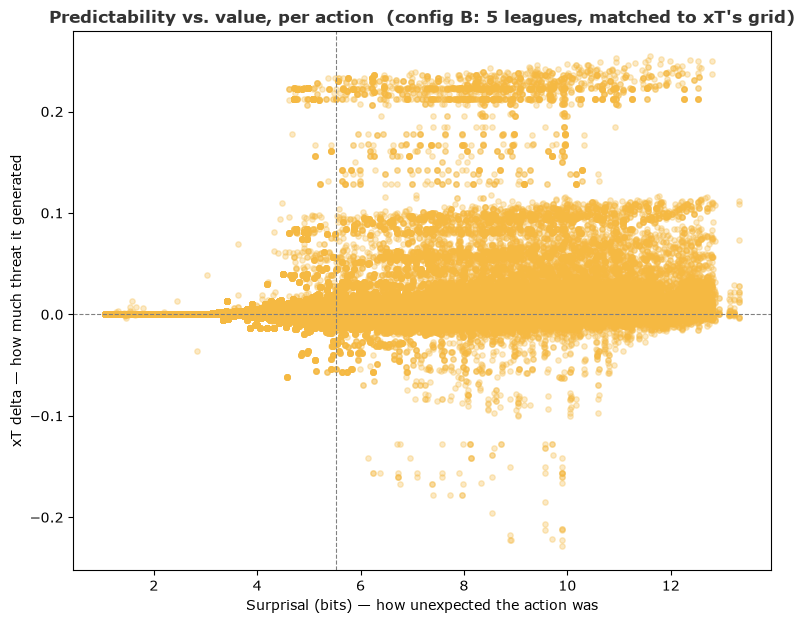

In [51]:
import matplotlib.pyplot as plt
from src.analytics.xt_model import _zone_index
from src.analytics.sequence_model import compute_action_surprise

model = result_b["model"]
test_sequences = result_b["test_sequences"]
tokenized = result_b["tokenized"]

print(f"vocab_size: {model['vocab_size']}")

action_surprise = compute_action_surprise(model, test_sequences)

test_ids = list({match_id for (match_id, _) in test_sequences.keys()})
tokenized_test = tokenized[tokenized["match_id"].isin(test_ids)].copy()
tokenized_test["position_in_possession"] = tokenized_test.groupby(["match_id", "possession"]).cumcount() + 1

merged = action_surprise.merge(
    tokenized_test[[
        "match_id", "possession", "position_in_possession",
        "player", "minute", "event_type", "x", "y", "end_x", "end_y",
    ]],
    on=["match_id", "possession", "position_in_possession"],
    how="left",
)

col_start, row_start = _zone_index(merged["x"].to_numpy(), merged["y"].to_numpy())
col_end, row_end = _zone_index(
    merged["end_x"].fillna(merged["x"]).to_numpy(),
    merged["end_y"].fillna(merged["y"]).to_numpy(),
)
merged["xt_start"] = xt_with_turnover[col_start, row_start]
merged["xt_end"] = xt_with_turnover[col_end, row_end]
merged["xt_delta"] = merged["xt_end"] - merged["xt_start"]

print(f"merged rows: {len(merged)}")

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(merged["surprise"], merged["xt_delta"], alpha=0.3, s=15, color="#f5b942")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.axvline(merged["surprise"].median(), color="gray", linewidth=0.8, linestyle="--")

ax.set_xlabel("Surprisal (bits) — how unexpected the action was")
ax.set_ylabel("xT delta — how much threat it generated")
ax.set_title("Predictability vs. value, per action  (config B: 5 leagues, matched to xT's grid)", color="#333", fontsize=12)

fig.savefig("xsurprise_vs_xt_3.png", dpi=150, bbox_inches="tight")